In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [3]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [4]:
import os
import json
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")

In [5]:
PROJECT_PATH = "/content/drive/MyDrive/BATTERY_SOC_PROJECT"
OUTPUT_PATH = os.path.join(PROJECT_PATH, "day20_outputs")
os.makedirs(OUTPUT_PATH, exist_ok=True)
print("Day 20 output folder:", OUTPUT_PATH)

Day 20 output folder: /content/drive/MyDrive/BATTERY_SOC_PROJECT/day20_outputs


In [6]:
def find_file(filename):
    matches = glob.glob(os.path.join(PROJECT_PATH, "**", filename),recursive=True)
    if not matches:
        return None
    return matches[0]

In [7]:
best_config_file = find_file("day19_best_validated_configuration.csv")
if best_config_file is None:
    raise FileNotFoundError("day19_best_validated_configuration.csv not found.")
best_config = pd.read_csv(best_config_file)
print("\nDay 19 best validated configurations:")
display(best_config)


Day 19 best validated configurations:


,Experiment,Model,Target,n_estimators,max_depth,min_samples_split,min_samples_leaf,Train_MAE,Train_RMSE,Train_R2,Validation_MAE,Validation_RMSE,Validation_R2,learning_rate,min_child_weight
0,RF_1_Baseline_Tuned,Random Forest,Remaining Charging Time,250,8,10.0,4.0,54.619269,259.753224,0.999612,66.009018,85.341677,0.996502,NaN,NaN
1,XGB_2_More_Regularization,XGBoost,SOC,300,2,NaN,NaN,1.250890,2.785292,0.995612,5.767199,8.348844,0.892573,0.03,5.0


In [8]:
soc_model_file = find_file("day19_best_SOC_XGBoost.joblib")
time_model_file = find_file("day19_best_Remaining_Charging_Time_Random_Forest.joblib")
if soc_model_file is None:
    raise FileNotFoundError("Day 19 SOC model not found.")
if time_model_file is None:
    raise FileNotFoundError("Day 19 Remaining Charging Time model not found.")
soc_loaded = joblib.load(soc_model_file)
time_loaded = joblib.load(time_model_file)

In [9]:
def extract_model(obj):
    if hasattr(obj, "predict"):
        return obj
    if isinstance(obj, dict):
        preferred_keys = ["model","estimator","pipeline","best_model","regressor","trained_model"]
        for key in preferred_keys:
            if key in obj and hasattr(
                obj[key],
                "predict"
            ):
                return obj[key]
        for value in obj.values():
            if hasattr(value, "predict"):
                return value
    raise TypeError( "Could not find trained model inside joblib file.")
soc_model = extract_model(soc_loaded)
time_model = extract_model(time_loaded)
print("\nSOC model:")
print(soc_model_file)
print("\nRemaining Time model:")
print(time_model_file)
print("\nActual SOC model type:")
print(type(soc_model))
print("\nActual Remaining Time model type:")
print(type(time_model))


SOC model:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day19_outputs/day19_best_SOC_XGBoost.joblib

Remaining Time model:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day19_outputs/day19_best_Remaining_Charging_Time_Random_Forest.joblib

Actual SOC model type:
<class 'xgboost.sklearn.XGBRegressor'>

Actual Remaining Time model type:
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [10]:
def get_model_features(model):

    if hasattr(model, "feature_names_in_"):
        features = list( model.feature_names_in_)
        if len(features) > 0:
            return features
    if hasattr(model, "get_booster"):
        try:
            features = list(model.get_booster().feature_names)
            if features:
                return features
        except Exception:
            pass
    if hasattr(model, "n_features_in_"):
        return None
    return None
soc_model_features = get_model_features(soc_model)
time_model_features = get_model_features(time_model)
print("\nExact features used by SOC model:")
if soc_model_features is not None:
    print(soc_model_features)
else:
    print(
        "Feature names not directly stored will use Day 13 feature list.")
print("\nExact features used by Remaining Time model:")
if time_model_features is not None:
    print(time_model_features)
else:
    print(
        "Feature names not directly stored will use Day 13 feature list.")


Exact features used by SOC model:
[np.str_('Voltage'), np.str_('Current'), np.str_('Temperature'), np.str_('Elapsed Time'), np.str_('Cycle'), np.str_('WhAccu'), np.str_('Power')]

Exact features used by Remaining Time model:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu', 'Power']


In [11]:
feature_file = find_file("final_feature_list_day13.json")
if feature_file is None:
    raise FileNotFoundError("final_feature_list_day13.json not found.")
with open(feature_file, "r") as f:
    feature_data = json.load(f)
if isinstance(feature_data, list):
    day13_features = feature_data
elif isinstance(feature_data, dict):
    if "features" in feature_data:
        day13_features = feature_data["features"]
    elif "selected_features" in feature_data:
        day13_features = feature_data[
            "selected_features"
        ]
    else:
        day13_features = []
        for value in feature_data.values():
            if isinstance(value, list):
                day13_features.extend(value)
        day13_features = list(dict.fromkeys(day13_features))
else:
    day13_features = []
print("\nDay 13 feature list:")
print(day13_features)


Day 13 feature list:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu', 'Power', 'Capacity']


In [12]:
if soc_model_features is None:
    SOC_FEATURES = day13_features
else:
    SOC_FEATURES = soc_model_features
if time_model_features is None:
    TIME_FEATURES = day13_features
else:
    TIME_FEATURES = time_model_features
print("\nFINAL SOC FEATURES USED:")
print(SOC_FEATURES)
print("\nFINAL REMAINING TIME FEATURES USED:")
print(TIME_FEATURES)


FINAL SOC FEATURES USED:
[np.str_('Voltage'), np.str_('Current'), np.str_('Temperature'), np.str_('Elapsed Time'), np.str_('Cycle'), np.str_('WhAccu'), np.str_('Power')]

FINAL REMAINING TIME FEATURES USED:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu', 'Power']


In [13]:
soc_test_file = find_file("SOC_test_engineered_day13.csv")
time_test_file = find_file("remaining_time_test_engineered_day13.csv")
if soc_test_file is None:
    raise FileNotFoundError("SOC_test_engineered_day13.csv not found.")
if time_test_file is None:
    raise FileNotFoundError("remaining_time_test_engineered_day13.csv not found.")
soc_test = pd.read_csv(soc_test_file)
time_test = pd.read_csv(time_test_file)
print("\nSOC test shape:")
print(soc_test.shape)
print("\nRemaining Time test shape:")
print(time_test.shape)


SOC test shape:
(2250, 10)

Remaining Time test shape:
(2286, 11)


In [14]:
def prepare_model_input(df,features):
    missing = [col for col in features
        if col not in df.columns
    ]
    if missing:
        raise ValueError(
            "The test dataset is missing features required "f"by the trained model: {missing}")
    X = df[features].copy()
    for col in X.columns:
        X[col] = pd.to_numeric( X[col],errors="coerce")
        if X[col].isna().all():X[col] = 0
        else:
            X[col] = X[col].fillna( X[col].median())
    return X
X_soc_test = prepare_model_input(soc_test,SOC_FEATURES)
X_time_test = prepare_model_input(time_test,TIME_FEATURES)
print("\nSOC model input shape:")
print(X_soc_test.shape)
print("\nRemaining Time model input shape:")
print(X_time_test.shape)


SOC model input shape:
(2250, 7)

Remaining Time model input shape:
(2286, 7)


In [15]:
print("\nGenerating SOC predictions...")
soc_predictions = soc_model.predict( X_soc_test)
print("SOC predictions generated successfully.")
print("\nGenerating Remaining Charging Time predictions...")
time_predictions = time_model.predict( X_time_test)
print("Remaining Charging Time predictions generated successfully.")


Generating SOC predictions...
SOC predictions generated successfully.

Generating Remaining Charging Time predictions...
Remaining Charging Time predictions generated successfully.


In [16]:
def find_target_column(
    df,
    names
):
    for name in names:
        if name in df.columns:
            return name
    return None
soc_target_col = find_target_column(
    soc_test,["SOC","SoC","soc"])
time_target_col = find_target_column(
    time_test,
    ["Remaining Charging Time","Remaining_Charging_Time","Remaining Charging Time (s)","remaining_time"]
)
if soc_target_col is None:
    raise ValueError(
        "SOC target column not found.")
if time_target_col is None:
    raise ValueError("Remaining Charging Time target column not found.")
y_soc = pd.to_numeric(soc_test[soc_target_col], errors="coerce")
y_time = pd.to_numeric(
    time_test[time_target_col],
    errors="coerce"
)

In [17]:
def calculate_metrics(y_true,y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    valid = ( np.isfinite(y_true)&np.isfinite(y_pred))
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    if len(y_true) == 0:
        return {"Samples": 0,"MAE": np.nan,"RMSE": np.nan,"R2": np.nan}
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    if (
        len(y_true) >= 2and np.unique(y_true).size > 1):
        r2 = r2_score(y_true,y_pred)
    else:
        r2 = np.nan
    return {
        "Samples": len(y_true),"MAE": mae,"RMSE": rmse,"R2": r2
    }

In [18]:
soc_overall = calculate_metrics(y_soc, soc_predictions)
time_overall = calculate_metrics(y_time,time_predictions)
overall_results = pd.DataFrame([
    {"Target": "SOC","Condition": "Overall Test",**soc_overall},
    {"Target": "Remaining Charging Time","Condition": "Overall Test",**time_overall}
])
print("\n------ OVERALL TEST RESULTS ------")
display(overall_results)


------ OVERALL TEST RESULTS ------


,Target,Condition,Samples,MAE,RMSE,R2
0,SOC,Overall Test,2250,1.35385,3.179452,0.994054
1,Remaining Charging Time,Overall Test,2286,542.10664,799.685272,0.998756


In [19]:
soc_prediction_df = soc_test.copy()
soc_prediction_df["Predicted_SOC"] = soc_predictions
soc_prediction_df["SOC_Error"] = (soc_prediction_df[soc_target_col]-soc_prediction_df["Predicted_SOC"])
soc_prediction_df["SOC_Absolute_Error"] = abs(soc_prediction_df["SOC_Error"])
time_prediction_df = time_test.copy()
time_prediction_df["Predicted_Remaining_Time"] = time_predictions
time_prediction_df["Remaining_Time_Error"] = (time_prediction_df[time_target_col] -time_prediction_df["Predicted_Remaining_Time"])
time_prediction_df["Remaining_Time_Absolute_Error"] = abs(time_prediction_df["Remaining_Time_Error"])
soc_prediction_df.to_csv(
    os.path.join(OUTPUT_PATH,"day20_SOC_test_predictions.csv"),index=False)
time_prediction_df.to_csv(
    os.path.join( OUTPUT_PATH,"day20_remaining_time_test_predictions.csv"),index=False)

In [20]:
SOC_RANGES = ["Low SOC (<=33.33%)","Mid SOC (33.33-66.67%)","High SOC (>66.67%)"]
def create_soc_ranges(df,soc_column):
    result = df.copy()
    values = pd.to_numeric(result[soc_column],errors="coerce")
    result["SOC_Range"] = pd.cut(
        values,bins=[-np.inf,33.33,66.67,np.inf],labels=SOC_RANGES,include_lowest=True)
    return result
soc_error_df = create_soc_ranges(soc_prediction_df,soc_target_col)
soc_range_rows = []
for condition in SOC_RANGES:
    subset = soc_error_df[soc_error_df["SOC_Range"] == condition]
    if len(subset) == 0:
        print(
            f"Skipping {condition} for SOC "
            "because there are 0 samples."
        )
        continue
    metrics = calculate_metrics(subset[soc_target_col],subset["Predicted_SOC"])
    soc_range_rows.append({"Target": "SOC","Condition": condition,**metrics})
soc_range_results = pd.DataFrame(soc_range_rows)
print(
    "\n------- SOC RANGE ROBUSTNESS ------")
display(soc_range_results)


------- SOC RANGE ROBUSTNESS ------


,Target,Condition,Samples,MAE,RMSE,R2
0,SOC,Low SOC (<=33.33%),1335,0.819682,1.987262,0.926022
1,SOC,Mid SOC (33.33-66.67%),226,1.887909,3.232713,0.887221
2,SOC,High SOC (>66.67%),689,2.213671,4.683148,0.745000


In [21]:
time_range_rows = []

time_soc_column = find_target_column(
    time_prediction_df,
    ["SOC","SoC","soc"]
)
if time_soc_column is not None:
    time_error_df = create_soc_ranges(time_prediction_df,time_soc_column)
    for condition in SOC_RANGES:
        subset = time_error_df[time_error_df["SOC_Range"] == condition]
        if len(subset) == 0:
            print(
                f"Skipping {condition} for Remaining Charging Time because there are 0 samples.")
            continue
        metrics = calculate_metrics(
            subset[time_target_col],
            subset["Predicted_Remaining_Time"])
        time_range_rows.append({
            "Target": "Remaining Charging Time",
            "Condition": condition,
            **metrics
        })
else:
    print(
        "\nRemaining Time test data has no explicit SOC column.")
    print(
        "SOC-range analysis for Remaining Charging Time is not applicable.")
time_range_results = pd.DataFrame(time_range_rows)
if not time_range_results.empty:
    print(
        "\n-------- REMAINING TIME SOC RANGE ROBUSTNESS ------")
    display(time_range_results)


Remaining Time test data has no explicit SOC column.
SOC-range analysis for Remaining Charging Time is not applicable.


In [22]:
robustness_parts = [overall_results,soc_range_results]
if not time_range_results.empty:
    robustness_parts.append(time_range_results)
robustness_table = pd.concat(
    robustness_parts,
    ignore_index=True
)
robustness_table["MAE_Difference_From_Overall"] = np.nan
robustness_table["MAE_Percent_Change"] = np.nan
for target in robustness_table["Target"].unique():
    overall_rows = robustness_table[
        (robustness_table["Target"] == target)
        &
        (
            robustness_table["Condition"]== "Overall Test"
        )
    ]
    if overall_rows.empty:
        continue
    overall_mae = overall_rows["MAE"].iloc[0]
    mask = (
        (robustness_table["Target"] == target)
        &
        (robustness_table["Condition"]!= "Overall Test")
    )
    robustness_table.loc[mask,"MAE_Difference_From_Overall"] = (robustness_table.loc[mask, "MAE"] -overall_mae)
    if overall_mae != 0:
        robustness_table.loc[mask,"MAE_Percent_Change"] = (( robustness_table.loc[mask,"MAE"]-overall_mae )/overall_mae) * 100
print("\n------- ROBUSTNESS / ABLATION TABLE -----")
display(robustness_table)
robustness_table.to_csv(
    os.path.join(OUTPUT_PATH,"day20_robustness_ablation_table.csv"),index=False)


------- ROBUSTNESS / ABLATION TABLE -----


,Target,Condition,Samples,MAE,RMSE,R2,MAE_Difference_From_Overall,MAE_Percent_Change
0,SOC,Overall Test,2250,1.353850,3.179452,0.994054,NaN,NaN
1,Remaining Charging Time,Overall Test,2286,542.106640,799.685272,0.998756,NaN,NaN
2,SOC,Low SOC (<=33.33%),1335,0.819682,1.987262,0.926022,-0.534168,-39.455485
3,SOC,Mid SOC (33.33-66.67%),226,1.887909,3.232713,0.887221,0.534059,39.447454
4,SOC,High SOC (>66.67%),689,2.213671,4.683148,0.745000,0.859821,63.509358


In [23]:
def error_summary(actual,predicted,target_name):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    valid = (np.isfinite(actual)&np.isfinite(predicted))
    actual = actual[valid]
    predicted = predicted[valid]
    if len(actual) == 0:
        return {"Target": target_name,"Mean_Error": np.nan,"Mean_Absolute_Error": np.nan,"Median_Absolute_Error": np.nan,"90th_Percentile_Absolute_Error": np.nan,"Maximum_Absolute_Error": np.nan,"RMSE": np.nan}
    error = actual - predicted
    abs_error = np.abs(error)
    return {"Target": target_name,"Mean_Error": np.mean(error),"Mean_Absolute_Error": np.mean(abs_error),
        "Median_Absolute_Error": np.median(abs_error),"90th_Percentile_Absolute_Error": np.percentile(abs_error,90),
        "Maximum_Absolute_Error": np.max(abs_error),
        "RMSE": np.sqrt(np.mean(error ** 2))}
error_analysis = pd.DataFrame([
    error_summary(y_soc,soc_predictions,"SOC"),
    error_summary( y_time,time_predictions,"Remaining Charging Time")])
print(
    "\n------- ERROR ANALYSIS ------")
display(error_analysis)
error_analysis.to_csv(
    os.path.join(OUTPUT_PATH,"day20_error_analysis.csv"),index=False)




------- ERROR ANALYSIS ------


,Target,Mean_Error,Mean_Absolute_Error,Median_Absolute_Error,90th_Percentile_Absolute_Error,Maximum_Absolute_Error,RMSE
0,SOC,0.09950,1.35385,0.454127,2.621832,32.558224,3.179452
1,Remaining Charging Time,492.81845,542.10664,437.463137,1335.971877,3260.411979,799.685272


In [24]:
def extract_feature_importance(model,features,target_name):
    if hasattr(
        model,
        "feature_importances_"
    ):
        importance = model.feature_importances_
    elif hasattr(
        model,
        "coef_"
    ):
        importance = np.abs(
            np.asarray(
                model.coef_)
        ).flatten()
    else:
        print(
            f"Feature importance unavailable "
            f"for {target_name}."
        )
        return pd.DataFrame()

    min_len = min(len(features),len(importance))
    result = pd.DataFrame({"Feature": features[:min_len],"Importance": importance[:min_len]})
    result = result.sort_values("Importance",ascending=False).reset_index(drop=True)
    result["Target"] = target_name
    return result
soc_importance = extract_feature_importance(soc_model,SOC_FEATURES,"SOC")
time_importance = extract_feature_importance(time_model,TIME_FEATURES,"Remaining Charging Time")
feature_importance = pd.concat(
    [soc_importance,time_importance],ignore_index=True)
print(
    "\n-------- TARGET-WISE FEATURE IMPORTANCE --------")
display(feature_importance)
feature_importance.to_csv(
    os.path.join(OUTPUT_PATH,"day20_targetwise_feature_importance.csv"),index=False)


-------- TARGET-WISE FEATURE IMPORTANCE --------


,Feature,Importance,Target
0,Voltage,0.472850,SOC
1,WhAccu,0.378971,SOC
2,Power,0.058619,SOC
3,Elapsed Time,0.041285,SOC
4,Current,0.028048,SOC
5,Temperature,0.020227,SOC
6,Cycle,0.000000,SOC
7,Elapsed Time,0.543546,Remaining Charging Time
8,WhAccu,0.304523,Remaining Charging Time
9,Cycle,0.038964,Remaining Charging Time


In [25]:
phase_results = []
possible_phase_columns = ["Status","Procedure","Step","Cycle Level"]
for column in possible_phase_columns:
    if column not in soc_prediction_df.columns:
        continue
    unique_values = (soc_prediction_df[column].dropna().unique())
    if len(unique_values) > 20:
        continue
    for value in unique_values:
        subset = soc_prediction_df[soc_prediction_df[column] == value]
        if len(subset) == 0:
            continue
        metrics = calculate_metrics(subset[soc_target_col],subset["Predicted_SOC"])
        phase_results.append({"Target": "SOC","Condition_Type": column,"Condition": str(value),**metrics})
phase_results_df = pd.DataFrame(phase_results)
if not phase_results_df.empty:
    print("\n------- CHARGING PHASE / STATUS ANALYSIS -------")
    display(phase_results_df)
    phase_results_df.to_csv(
        os.path.join( OUTPUT_PATH,"day20_charging_phase_analysis.csv"),index=False)
else:
    print("\nNo suitable charging phase/status variable was available.")


No suitable charging phase/status variable was available.


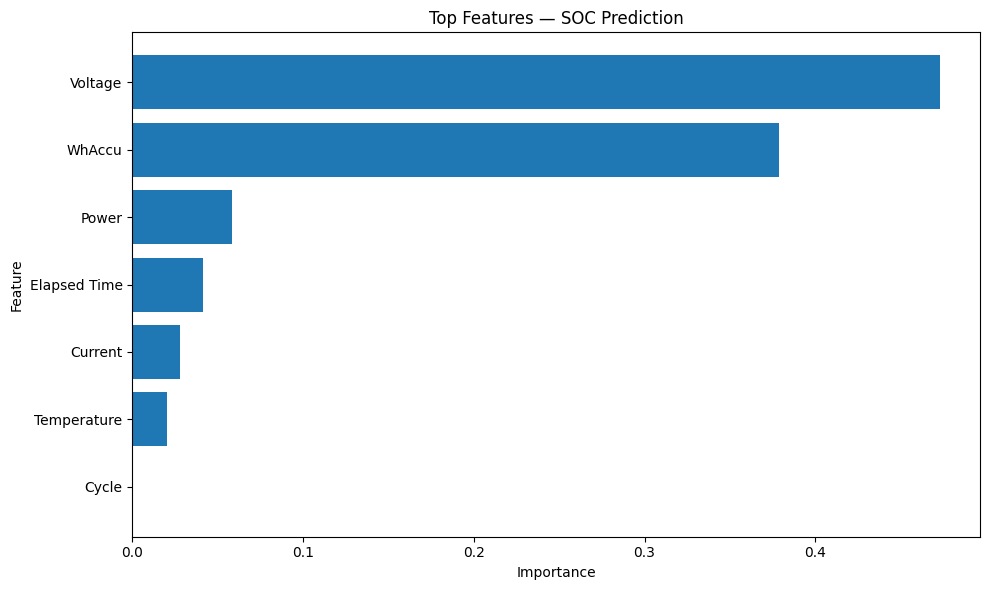

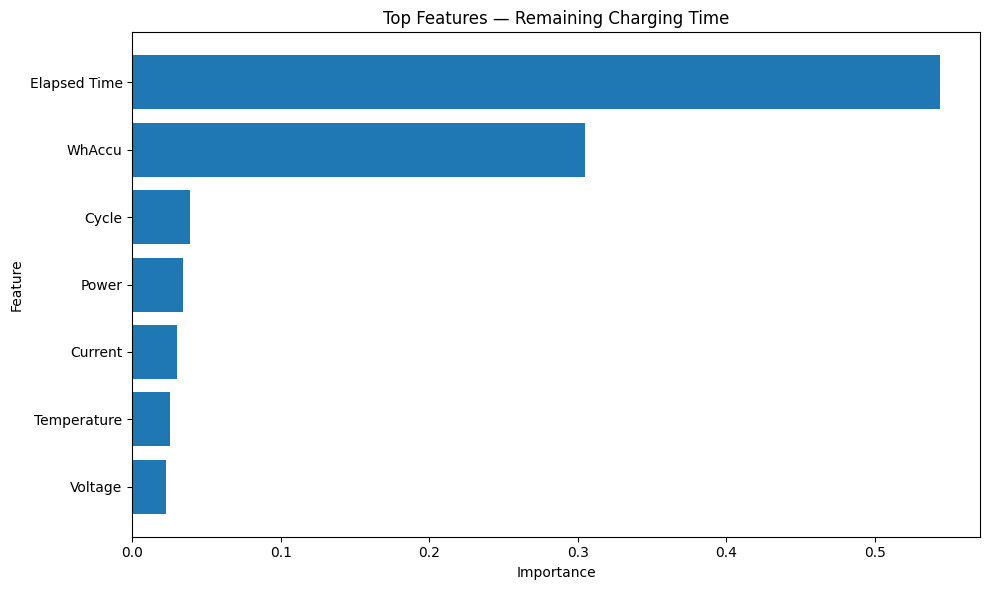

In [26]:
if not soc_importance.empty:
    top_soc = soc_importance.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top_soc["Feature"][::-1],top_soc["Importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top Features — SOC Prediction")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH,"day20_SOC_feature_importance.png"),dpi=300)
    plt.show()
if not time_importance.empty:
    top_time = time_importance.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top_time["Feature"][::-1],top_time["Importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top Features — Remaining Charging Time")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_PATH,"day20_remaining_time_feature_importance.png"),dpi=300)
    plt.show()

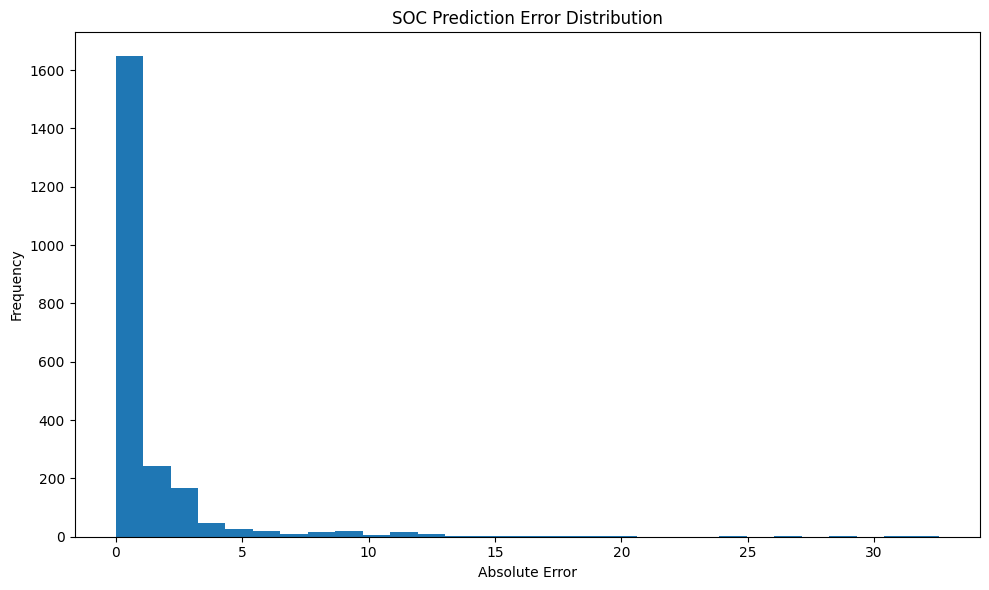

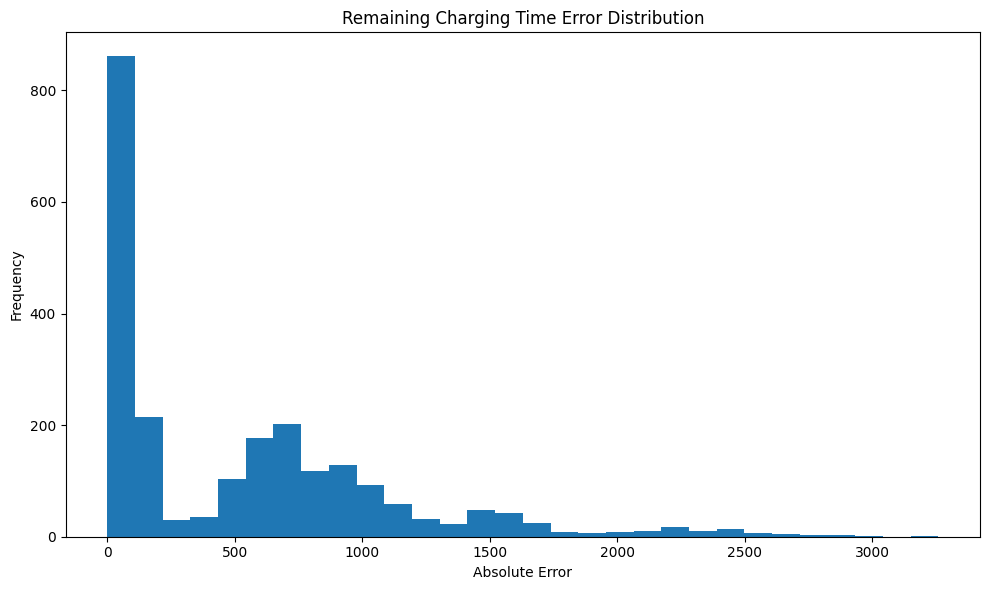

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(soc_prediction_df["SOC_Absolute_Error"].dropna(),bins=30)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("SOC Prediction Error Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,"day20_SOC_error_distribution.png"),dpi=300)
plt.show()
plt.figure(figsize=(10, 6))
plt.hist(time_prediction_df["Remaining_Time_Absolute_Error"].dropna(),bins=30)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Remaining Charging Time Error Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,"day20_remaining_time_error_distribution.png"),dpi=300)
plt.show()

In [28]:
research_lines = []
for target in ["SOC","Remaining Charging Time"]:
    subset = robustness_table[
        (robustness_table["Target"] == target)
        &
        (robustness_table["Condition"]!= "Overall Test")
    ].dropna(subset=["MAE"]
    )
    if subset.empty:
        continue
    best_row = subset.loc[subset["MAE"].idxmin()]
    worst_row = subset.loc[subset["MAE"].idxmax()]
    research_lines.append(
        f"{target}: lowest MAE was observed in "
        f"{best_row['Condition']} "
        f"({best_row['MAE']:.4f}), while the "
        f"highest MAE was observed in "
        f"{worst_row['Condition']} "
        f"({worst_row['MAE']:.4f})."
    )

In [30]:
research_lines.append("Day 20 evaluated the robustness of the selected Day 19 models using the frozen Day 13 test set.")
research_lines.append("The analysis examined overall prediction performance, SOC-range behaviour, target-wise feature importance, and prediction errors.")
research_lines.append("The results identify operating regions where the selected models perform relatively well and regions where prediction error is higher.")
if not phase_results_df.empty:
    research_lines.append("Charging-status/phase-wise analysis was also performed where suitable categorical information was available.")
else:
    research_lines.append("A separate charging-phase analysis was not performed because no suitable low-cardinality phase/status variable was available.")
with open(os.path.join(OUTPUT_PATH,"day20_research_insight.txt"),
    "w"
) as f:
    for line in research_lines:
        f.write(line + "\n")

In [31]:
summary = {
    "Day": 20,
    "Study_Type":"Project-Specific Robustness and Error Analysis",
    "Model_Selection_From_Day":19,
    "Test_Set":"Frozen Day 13 test set",
    "SOC_Model":"Day 19 Best XGBoost",
    "Remaining_Time_Model":"Day 19 Best Random Forest",
    "SOC_Features":SOC_FEATURES,
    "Remaining_Time_Features":TIME_FEATURES,
    "SOC_Test_Samples":int(len(y_soc)),
    "Remaining_Time_Test_Samples":int(len(y_time)),
    "SOC_Range_Analysis":True,
    "Target_Wise_Feature_Importance":True,
    "Error_Analysis":True,
    "Charging_Phase_Analysis":not phase_results_df.empty
}
with open(
    os.path.join(OUTPUT_PATH,"day20_summary.json"),
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=4
    )

In [32]:
print("\nMain outputs saved in:")
print(OUTPUT_PATH)
print("\nDeliverables:")
print("1. day20_robustness_ablation_table.csv")
print("2. day20_targetwise_feature_importance.csv")
print("3. day20_error_analysis.csv")
print("4. day20_research_insight.txt")
print("5. day20_summary.json")
print("6. day20_SOC_test_predictions.csv")
print("7. day20_remaining_time_test_predictions.csv")
print("8. Feature importance plots")
print("9. Error distribution plots")


Main outputs saved in:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day20_outputs

Deliverables:
1. day20_robustness_ablation_table.csv
2. day20_targetwise_feature_importance.csv
3. day20_error_analysis.csv
4. day20_research_insight.txt
5. day20_summary.json
6. day20_SOC_test_predictions.csv
7. day20_remaining_time_test_predictions.csv
8. Feature importance plots
9. Error distribution plots
